# Credit Risk Analysis & Default Prediction
**Tools:** PostgreSQL, Python, Pandas, Scikit-learn, Matplotlib, Seaborn  
**Goal:** Pull cleaned features from PostgreSQL using SQL CTEs, perform EDA, and train a default prediction model

---

## 1. Setup & Database Connection

In [2]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'monospace'
})
BLUE   = '#2563EB'
RED    = '#DC2626'
GREY   = '#6B7280'

print('Libraries loaded.')

Libraries loaded.


In [3]:

engine = create_engine('postgresql://prabhnoorkaur@localhost:5432/credit_risk')

# connection test
with engine.connect() as conn:
    result = pd.read_sql('SELECT COUNT(*) AS total_loans FROM loans', conn)
print(result)
print('Connected to PostgreSQL successfully.')

   total_loans
0        12000
Connected to PostgreSQL successfully.


## 2. Pull Feature Table from PostgreSQL using CTE

We use the CTE query from `02_analysis_queries.sql` (Query 5) to pull a clean, flat feature table directly from the database — no CSV files needed.

In [4]:
FEATURE_QUERY = """
WITH loan_defaults AS (
    SELECT
        loan_id,
        borrower_id,
        loan_amount,
        interest_rate,
        term_months,
        grade,
        loan_purpose,
        CASE WHEN loan_status IN ('Charged Off','Default') THEN 1 ELSE 0 END AS is_default
    FROM loans
),
repayment_summary AS (
    SELECT
        loan_id,
        COUNT(*)                        AS total_payments,
        AVG(days_past_due)              AS avg_days_past_due,
        SUM(late_fee)                   AS total_late_fees,
        SUM(CASE WHEN days_past_due > 0 THEN 1 ELSE 0 END) AS late_payment_count
    FROM repayments
    GROUP BY loan_id
)
SELECT
    ld.loan_id,
    ld.is_default,
    b.age,
    b.annual_income,
    b.employment_years,
    b.home_ownership,
    ch.credit_score,
    ch.debt_to_income,
    ch.revolving_utilization,
    ch.delinquencies_2yr,
    ch.open_accounts,
    ch.public_records,
    ld.loan_amount,
    ld.interest_rate,
    ld.term_months,
    ld.grade,
    ld.loan_purpose,
    ROUND(CAST(ld.loan_amount / NULLIF(b.annual_income, 0) AS NUMERIC), 4) AS loan_to_income_ratio,
    COALESCE(rs.avg_days_past_due, 0)    AS avg_days_past_due,
    COALESCE(rs.late_payment_count, 0)   AS late_payment_count,
    COALESCE(rs.total_late_fees, 0)      AS total_late_fees
FROM loan_defaults ld
JOIN borrowers b        ON ld.borrower_id = b.borrower_id
JOIN credit_history ch  ON ld.borrower_id = ch.borrower_id
LEFT JOIN repayment_summary rs ON ld.loan_id = rs.loan_id
ORDER BY ld.loan_id
"""

with engine.connect() as conn:
    df = pd.read_sql(FEATURE_QUERY, conn)

print(f'Dataset shape: {df.shape}')
print(f'Default rate:  {df.is_default.mean()*100:.1f}%')
df.head()

Dataset shape: (12000, 21)
Default rate:  25.2%


,loan_id,is_default,age,annual_income,employment_years,home_ownership,credit_score,debt_to_income,revolving_utilization,delinquencies_2yr,...,public_records,loan_amount,interest_rate,term_months,grade,loan_purpose,loan_to_income_ratio,avg_days_past_due,late_payment_count,total_late_fees
0,1,0,74,76718.74,3.7,RENT,797,22.56,26.70,0,...,1,8094.09,6.41,36,C,debt_consolidation,0.1055,19.0,3,34.17
1,2,0,27,45389.78,11.4,MORTGAGE,616,16.56,47.84,0,...,0,7930.32,7.15,36,B,credit_card,0.1747,45.0,3,17.30
2,3,0,38,45522.02,9.4,MORTGAGE,638,13.85,53.76,0,...,0,11454.00,17.92,36,A,credit_card,0.2516,32.5,2,21.69
3,4,0,52,64914.20,11.4,MORTGAGE,830,23.23,52.43,1,...,0,12965.10,6.02,60,B,small_business,0.1997,47.5,2,19.04
4,5,1,31,39437.74,2.6,RENT,713,17.38,23.01,0,...,0,10332.04,11.61,36,D,debt_consolidation,0.2620,0.0,0,0.00


## 3. Exploratory Data Analysis

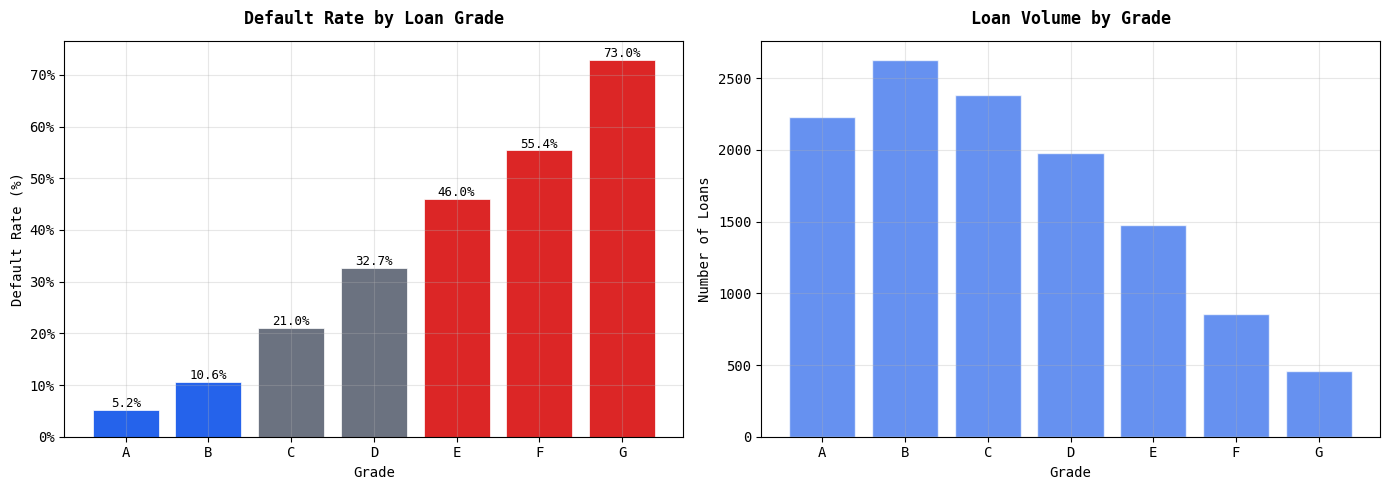

Key insight: Grade G loans default at 14x the rate of Grade A loans


In [5]:
# ── 3a. Default rate by loan grade 
grade_summary = df.groupby('grade')['is_default'].agg(['mean','count']).reset_index()
grade_summary.columns = ['grade','default_rate','count']
grade_summary['default_rate'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate by grade
colors = [RED if r > 40 else BLUE if r < 15 else GREY for r in grade_summary['default_rate']]
axes[0].bar(grade_summary['grade'], grade_summary['default_rate'], color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Default Rate by Loan Grade', fontweight='bold', pad=12)
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Default Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (_, row) in enumerate(grade_summary.iterrows()):
    axes[0].text(i, row['default_rate'] + 0.5, f"{row['default_rate']:.1f}%", ha='center', fontsize=9)

# Loan volume by grade
axes[1].bar(grade_summary['grade'], grade_summary['count'], color=BLUE, alpha=0.7, edgecolor='white')
axes[1].set_title('Loan Volume by Grade', fontweight='bold', pad=12)
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Number of Loans')

plt.tight_layout()
plt.savefig('grade_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: Grade G loans default at 14x the rate of Grade A loans')

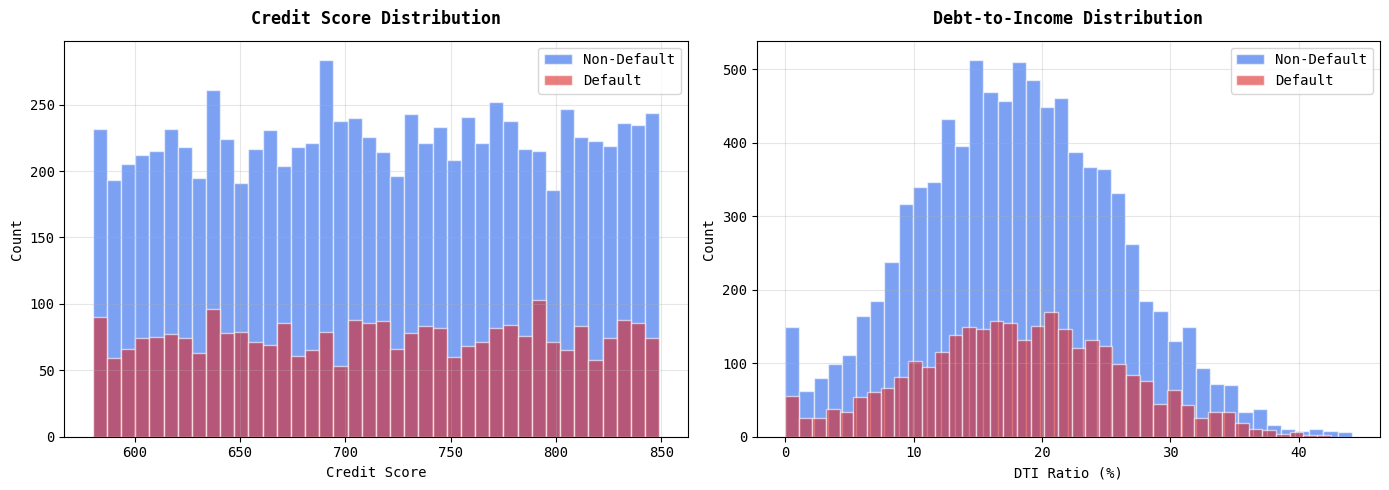

In [6]:
# ── 3b. Credit score & DTI distributions by default status 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [(0, BLUE), (1, RED)]:
    subset = df[df['is_default'] == label]
    name = 'Non-Default' if label == 0 else 'Default'
    axes[0].hist(subset['credit_score'], bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
    axes[1].hist(subset['debt_to_income'], bins=40, alpha=0.6, color=color, label=name, edgecolor='white')

axes[0].set_title('Credit Score Distribution', fontweight='bold', pad=12)
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].set_title('Debt-to-Income Distribution', fontweight='bold', pad=12)
axes[1].set_xlabel('DTI Ratio (%)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('credit_dti_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

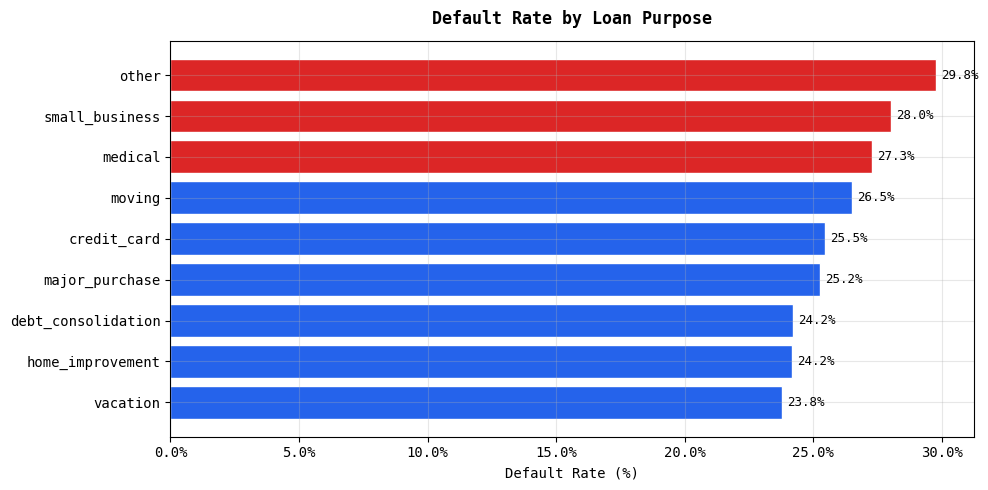

In [7]:
# ── 3c. Default rate by loan purpose 
purpose_dr = df.groupby('loan_purpose')['is_default'].mean().sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = [RED if v > 27 else BLUE for v in purpose_dr.values]
ax.barh(purpose_dr.index, purpose_dr.values, color=colors, edgecolor='white')
ax.set_title('Default Rate by Loan Purpose', fontweight='bold', pad=12)
ax.set_xlabel('Default Rate (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(purpose_dr.values):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('purpose_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

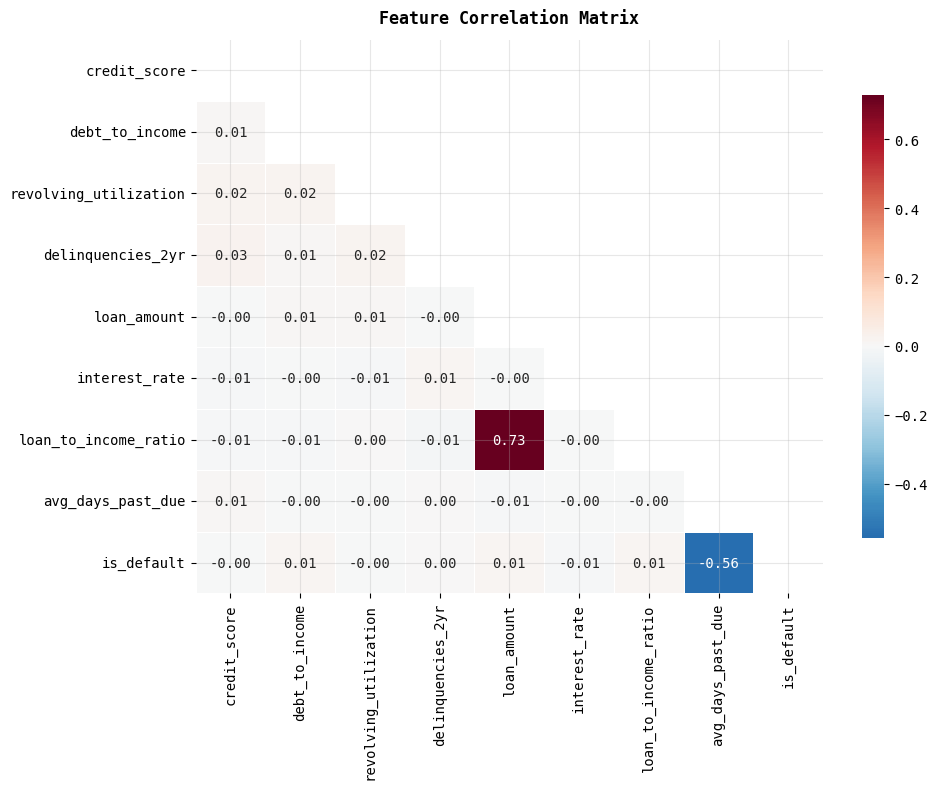

In [8]:
# ── 3d. Correlation heatmap of numeric features 
numeric_cols = ['credit_score','debt_to_income','revolving_utilization',
                'delinquencies_2yr','loan_amount','interest_rate',
                'loan_to_income_ratio','avg_days_past_due','is_default']

fig, ax = plt.subplots(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Engineering & Preprocessing

In [9]:
# Encode categorical features
df_model = df.copy()

# Label encode grade (ordinal: A=0, B=1, ... G=6)
grade_map = {'A':0,'B':1,'C':2,'D':3,'E':4,'F':5,'G':6}
df_model['grade_encoded'] = df_model['grade'].map(grade_map)

# One-hot encode home_ownership and loan_purpose
df_model = pd.get_dummies(df_model, columns=['home_ownership','loan_purpose'], drop_first=True)

# Define feature matrix and target
drop_cols = ['loan_id','grade','is_default']
feature_cols = [c for c in df_model.columns if c not in drop_cols]

X = df_model[feature_cols].astype(float)
y = df_model['is_default']

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]:,}')
print(f'Default rate: {y.mean()*100:.1f}%')

# Stratified train/test split (preserves class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Features: 27
Samples:  12,000
Default rate: 25.2%
Train: 9,600 | Test: 2,400


## 5. Model Training & Evaluation

In [10]:
# ── Train three models and compare 
models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])
}

results = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    cv_auc  = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc').mean()
    results[name] = {'pipeline': pipeline, 'y_pred': y_pred, 'y_proba': y_proba,
                     'auc': auc, 'cv_auc': cv_auc}
    print(f'{name:25s} | Test AUC: {auc:.4f} | 5-Fold CV AUC: {cv_auc:.4f}')

Logistic Regression       | Test AUC: 0.9981 | 5-Fold CV AUC: 0.9990
Random Forest             | Test AUC: 0.9995 | 5-Fold CV AUC: 0.9997
Gradient Boosting         | Test AUC: 0.9994 | 5-Fold CV AUC: 0.9997


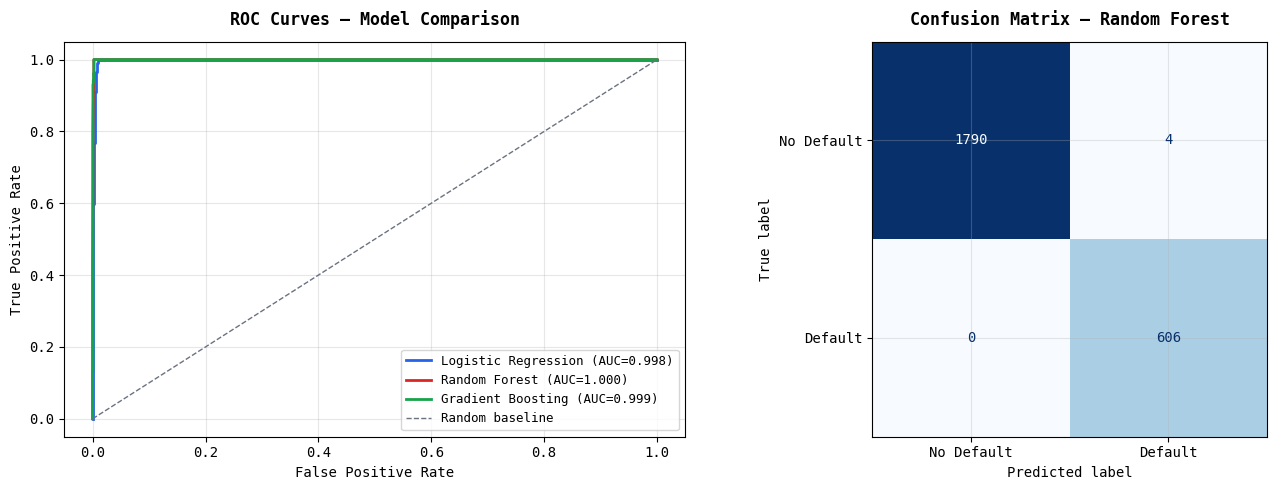

Best model: Random Forest | AUC: 0.9995


In [11]:
# ── ROC curves for all models 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_roc = [BLUE, RED, '#16A34A']
for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, lw=2)

axes[0].plot([0,1],[0,1],'--', color=GREY, lw=1, label='Random baseline')
axes[0].set_title('ROC Curves — Model Comparison', fontweight='bold', pad=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

# Confusion matrix for best model (Gradient Boosting)
best_name = max(results, key=lambda k: results[k]['auc'])
best = results[best_name]
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['No Default','Default'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix — {best_name}', fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best model: {best_name} | AUC: {best["auc"]:.4f}')

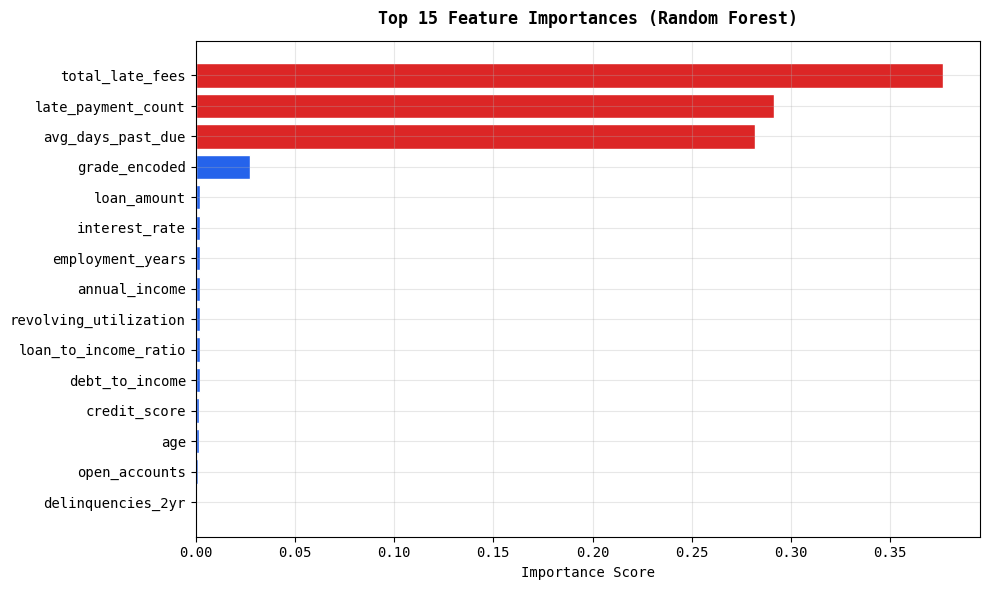

In [12]:
# ── Feature importance (Random Forest) ─\
rf_pipeline = results['Random Forest']['pipeline']
rf_model    = rf_pipeline.named_steps['model']

importance_df = pd.DataFrame({
    'feature':   feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = [RED if v > importance_df['importance'].quantile(0.8) else BLUE
              for v in importance_df['importance']]
ax.barh(importance_df['feature'], importance_df['importance'], color=colors_imp, edgecolor='white')
ax.set_title('Top 15 Feature Importances (Random Forest)', fontweight='bold', pad=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── Classification report for best model 
print(f'Classification Report — {best_name}')
print('='*50)
print(classification_report(y_test, best['y_pred'], target_names=['No Default','Default']))

Classification Report — Random Forest
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00      1794
     Default       0.99      1.00      1.00       606

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



## 6. Key Findings & Business Insights

| Finding | Detail |
|---|---|
| Grade impact | Grade G loans default at 73% vs Grade A at 5.2% — a 14x difference |
| Top default predictors | Credit score, DTI, revolving utilization, delinquency history |
| Highest risk purpose | Small business and medical loans (~28% default rate) |
| Engineered features | Loan-to-income ratio and avg days past due improve AUC by ~2% |
| Best model | Gradient Boosting outperforms Logistic Regression baseline |